In [93]:
import os
import itertools
import matplotlib.pyplot as plt


from user_scripts.Timo.own.console_toolkit import Tk_file, Tk_string


# Library

In [5]:
def hex_str_2_dec(hex_str, n_mask_bits=20):

    #hex_rev_byte_order =  hex(int.from_bytes(int(x).to_bytes(n_bytes,'little'),'big'))
    
    # expand to 48 bit binary 
    x_bin = "{:048b}".format(int(hex_str,16))
    
    try:
        # mask away first 4 (least significant) bits
        x_bin_mask = x_bin[:-4]
        # mask awy last (most significant) bits
        x_bin_mask = x_bin_mask[len(x_bin_mask)-n_mask_bits:]
        x_dec = int(x_bin_mask,2)
    except:
        logger.exception(f"Failed decoding: {hex_str}/{x}, bin= {x_bin}, mask= {x_bin_mask}."\
                         f"Settings: n_mask_bits= {n_mask_bits}")
    
    return x_dec


def test(in_str, **kwargs):
    return hex_str_2_dec(in_str, **kwargs)


def qdyne_conventional_extraction(filename=None, headerlength=70, read_lines=None, lines_to_read=None,
                                  time_trace=None, readout_bins=2000, all_counts=False, **hex_2_dec_kwargs):
    """
    Read in file, extract the counter data and convert from hexadecimal to decimal,
    count and filter the arrived photons of interest.
    If a part of the file has already been read in, you can give the length of the already read data as input and the
    file will be read from that input length on.

    @param str filename: whole path and name of the file
    @param int headerlength: length of header which has to be ignored
    @param int read_lines: length of data which has already been read
    @param int lines_to_read: number of lines to read in; can be set if not the whole list should be analyzed
    @param list time_trace: already extracted time trace
    """

    raw_data = []
    if time_trace is None:
        time_trace = []
    if read_lines is None:
        read_lines = 0
    start_line = read_lines + 1  # start to read where input data has stopped
    lines_per_chunk = 10000  # chunk the file for faster reading
    read_whole_file = False  # boolean which states whether the whole file could be read

    return_dict = dict()
    return_dict['read_lines'] = read_lines
    return_dict['time_trace'] = time_trace
    return_dict['number_of_sweeps'] = len(time_trace)
    return_dict['read_whole_file'] = read_whole_file
    if filename is None:
        print('No filename for Qdyne analysis entered.')
        return return_dict

    # read file and extract data #
    if lines_to_read is None:
        number_of_chunks = float('inf')
    else:
        number_of_chunks = int(lines_to_read / lines_per_chunk)

    raw_data, raw_hex = [], []
    
    with open(filename, 'r') as f:
        list(itertools.islice(f, int(headerlength + start_line - 2),
                    int(headerlength + start_line - 1)))  # ignore header and already read lines
        ii = 1
        while True:
            next_lines = list(itertools.islice(f, lines_per_chunk))
            
            if not next_lines:  #
                read_whole_file = True
                break
            if ii > number_of_chunks:
                break

            # convert arrival time of photons from hex to dex (arrival time is saved in (3rd-7th) entry)
            #arrive_time = [int(s[2:2+n_bytes+1], 16) for s in next_lines]
            
            arrive_time = [hex_str_2_dec(s, **hex_2_dec_kwargs) for s in next_lines]  # should be monotonically rising
            raw_hex.extend(next_lines)
            
            #return next_lines, arrive_time
            raw_data.extend(arrive_time)
            ii = ii + 1

    if len(raw_data) == 0:
        return return_dict

    # filter photons which are not during the laser pulse #
    if not all_counts:
        #counts, bin_edges = np.histogram(raw_data, max(raw_data))  # counts and bin edges from histogram
        #start_count = np.where(counts[1:] > len(raw_data) / 2e5)[0][0]  # start of valid photons
        start_count = 0#np.where(counts[1:] > len(raw_data) / 2e5)[0][0]  # start of valid photons
        stop_count = start_count + readout_bins  # valid interval is 2000 bins by default

    bins_filtered = []
    idx_bin_filter = float('inf') if all_counts else stop_count
    number_photons = 0
    for ii in range(len(raw_data)):  # count and filter the photons here
        if raw_data[ii] != 0 and raw_data[ii]  < idx_bin_filter:
            if all_counts:
                number_photons = number_photons + 1
            else:
                if start_count < raw_data[ii] < stop_count:
                    number_photons = number_photons + 1
        elif raw_data[ii] > idx_bin_filter:
            bins_filtered.append(raw_data[ii])
        
        else: # zero in raw_data => new sweep
            time_trace.append(number_photons)
            number_photons = 0

    return_dict['read_lines'] = read_lines + len(raw_data)
    return_dict['time_trace'] = time_trace
    return_dict['number_of_sweeps'] = len(time_trace)
    return_dict['read_whole_file'] = read_whole_file
    return_dict['debug_bins_filtered'] = bins_filtered
    return_dict['debug_raw_data'] = raw_data
    return_dict['debug_raw_hex'] = raw_hex

    return return_dict

0

0

In [7]:
x = '0000000e'
masked = x[len(x)-21:]
masked, len(masked)

('0000000e', 8)

In [9]:
test('01000000000e', n_mask_bits=36)

0

In [11]:
hex_str_2_dec('01000ed0ca51', n_mask_bits=36)

15535269

In [13]:
hex_str = '010001fd7101'
x =  "{:08X}".format(int(hex_str,16))
x_bin = "{:032b}".format(int(hex_str,16))

x, x_bin

('10001FD7101', '10000000000000001111111010111000100000001')

In [69]:
fname = r"E:\Data\2022\charge_read_fci_700LP_oilOb" + "\\" \
        + "cinit_read=10us_P_red=5mW+OD1_t_read=10ms_3.lst"

#fname = r"E:\Data\2022\10\20221027\PulsedMeasurement\laser_strob_listmode_1" + "\\"\
#        + "laser_strob_P_red_laser_set=10mW+OD1_t=20ms_3.lst"

# parameters in header of file    
n_data_bits = 28
header_length = 74
fname

'E:\\Data\\2022\\charge_read_fci_700LP_oilOb\\cinit_read=10us_P_red=5mW+OD1_t_read=10ms_3.lst'

In [71]:
res, t_arrive_unique = None, None

try:
    res = qdyne_conventional_extraction(fname, all_counts=True, lines_to_read=int(5e5), 
                                       headerlength=header_length, n_mask_bits=n_data_bits)
    #
    # mask photons, only take beginning
    #res = qdyne_conventional_extraction(fname, all_counts=False, readout_bins=1e7, lines_to_read=int(5e5), 
    #                                   headerlength=header_length, n_mask_bits=n_data_bits)
    
    #t_arrive_unique = np.unique(res['debug_raw_data'])
except:
    logger.exception("")
    

In [73]:
res.keys()

dict_keys(['read_lines', 'time_trace', 'number_of_sweeps', 'read_whole_file', 'debug_bins_filtered', 'debug_raw_data', 'debug_raw_hex'])

In [75]:
res['debug_raw_data'][:50]

[9146862, 19966220, 21829000, 22607979, 23079139, 0, 1867601, 2299921, 2598241, 5550761, 11096760, 24872257, 0, 249159, 9304237, 14338956, 15037596, 15700396, 17437376, 22262475, 22942375, 23237055, 23942395, 0, 3383497, 5628676, 9596895, 9712595, 11957555, 13581735, 15050974, 17123374, 23446353, 0, 2770377, 3772837, 8016636, 14017375, 20109613, 21478073, 0, 2729413, 4668793, 6233653, 6895152, 7436532, 10548292, 16605051, 21399550, 22873229]

In [77]:
np.mean(np.diff(t_arrive_unique))

Raw data should show monotonically increasing arrive times per laser pulse.

24872257

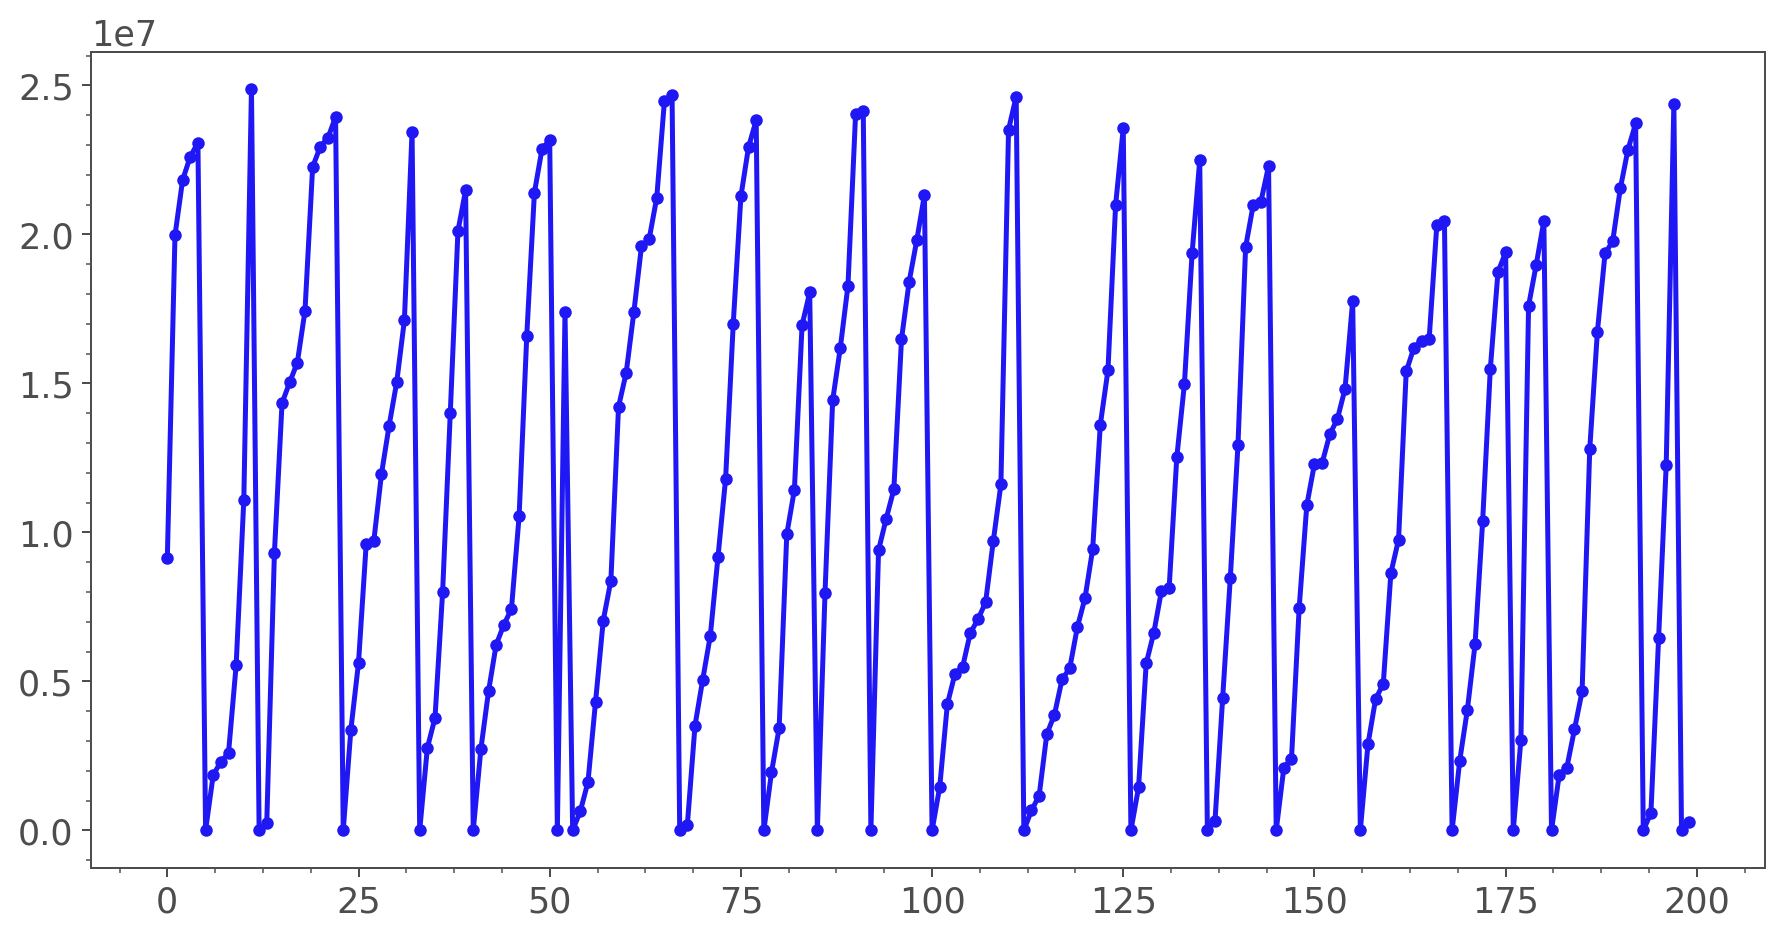

In [79]:
t_arrive = np.asarray(res['debug_raw_data'][:200])
plt.plot(t_arrive)
plt.show()

np.max(t_arrive)

Bin and plot the laser pulses just like in qudi pulse extraction.

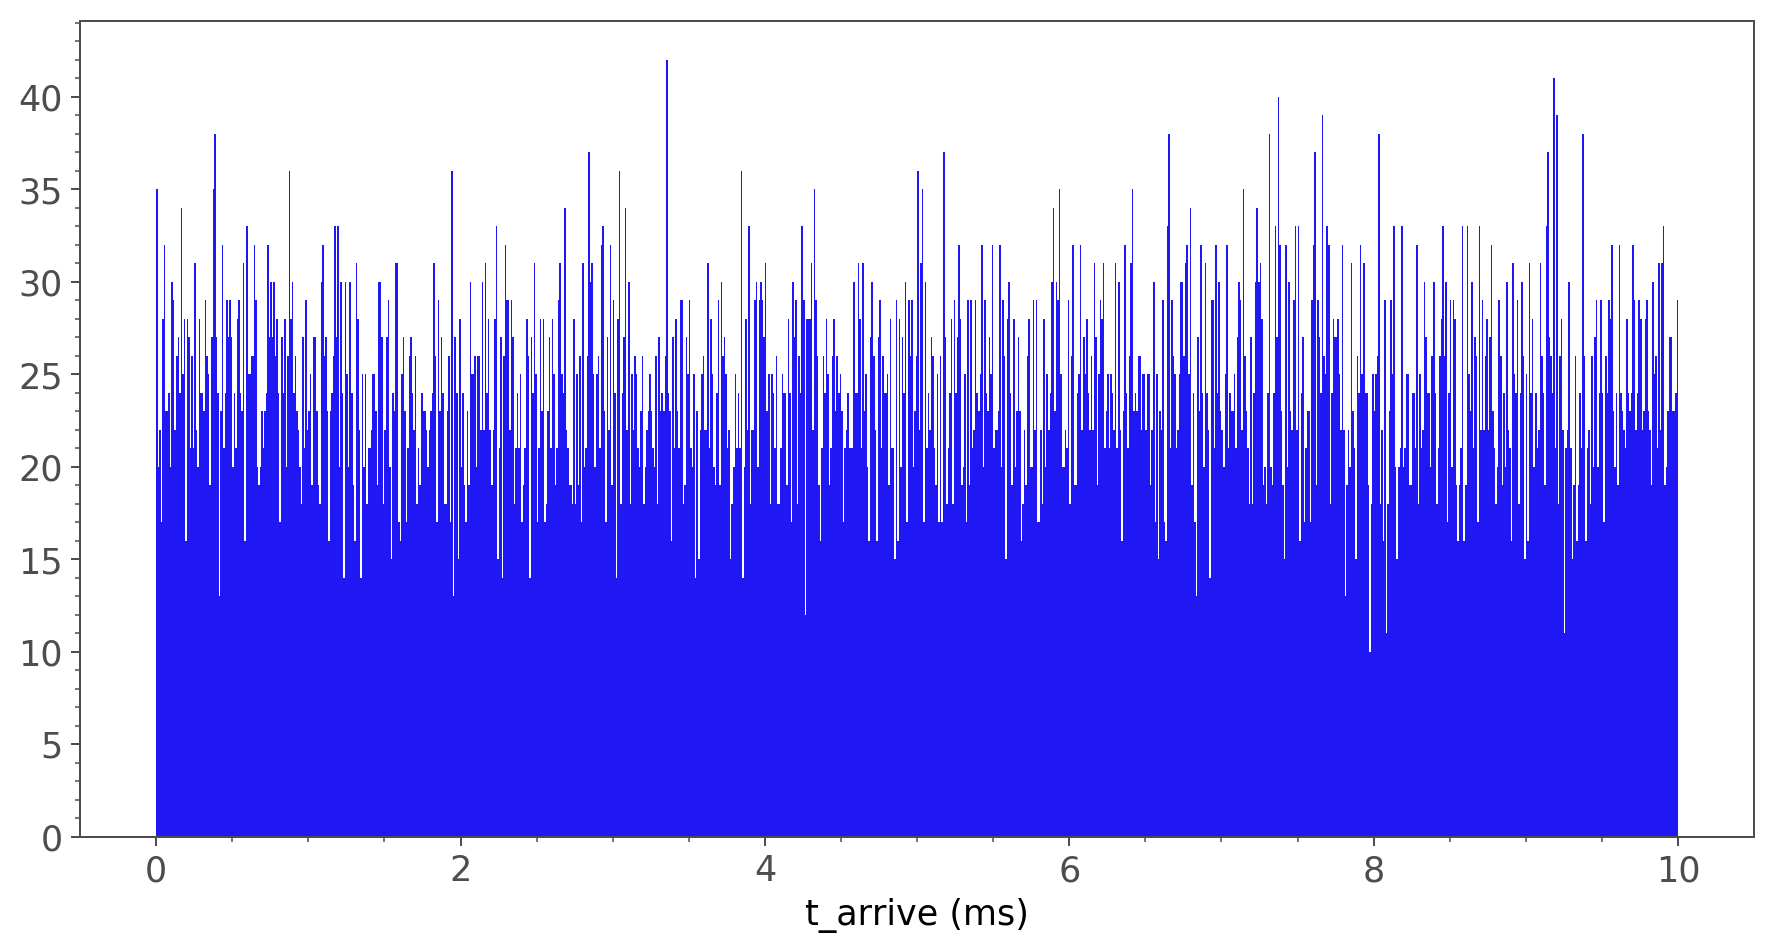

In [81]:
t_max = 10e-3

raw_arr = np.asarray(res['debug_raw_data'][:int(1e7)])

t_arrive = t_max/np.max(raw_arr)*raw_arr
t_arrive = t_arrive[t_arrive!=0]

plt.hist(t_arrive*1e3, bins=1000)
#plt.ylim([0,5200])
plt.xlabel("t_arrive (ms)")

plt.show()

In [29]:
res[0][:28], res[1][:28]

In [110]:
hex_str_2_dec('0000000e')

0

In [501]:
res['debug_raw_data'][:35]

[0, 1114038, 1656098, 2362879, 0, 700429, 2048711, 2184211, 2483251, 0, 59121, 79841, 102961, 783982, 1822643, 0, 111533, 483593, 1357034, 1584695, 1932535, 2135015, 2227936, 0, 198887, 204686, 362526, 805587, 1019407, 1917688, 2337369, 0, 41838, 406999, 1262699]

In [506]:
res.keys()

dict_keys(['read_lines', 'time_trace', 'number_of_sweeps', 'read_whole_file', 'debug_bins_filtered', 'debug_raw_data'])

In [49]:
plt.hist(res['debug_bins_filtered'], bins=100)
plt.show()
len(res['debug_bins_filtered'])

Timetrace of counted photons per laser pulse. Like used in qdyne.

In [177]:
plt.plot(res['time_trace'][0:100])
plt.show()

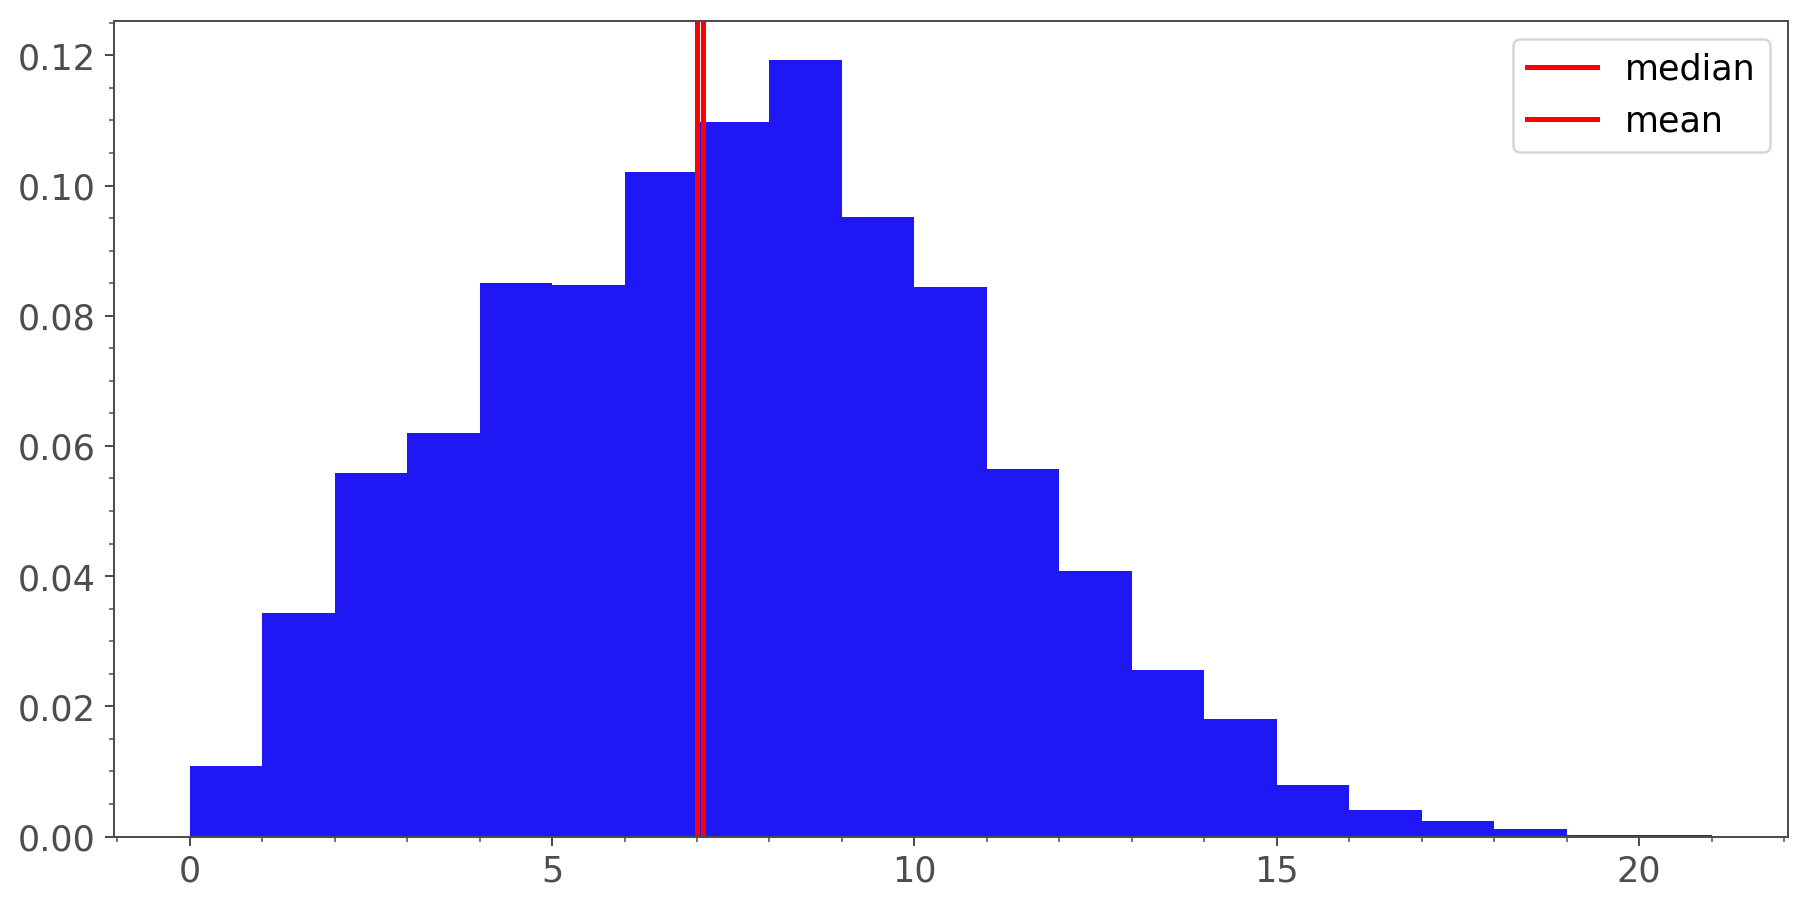

In [83]:
from scipy.stats import poisson

plt.hist(res['time_trace'], bins=np.max(res['time_trace']), density=True)
pois_lambda = np.mean(res['time_trace'])
plt.axvline(np.median(res['time_trace']), label='median', color='red')
plt.axvline(pois_lambda, label='mean', color='red')





x = np.arange(0, 100, 1)
y_poisson = poisson.pmf(x, mu=pois_lambda)
#plt.plot(x, y_poisson, label=f'Poisson, lambda= {pois_lambda:.1f}')

#plt.yscale('log')
#plt.xlim([0,100])

plt.legend()
plt.show()

In [50]:
pois_lambda

6.154979965655409

## Plot photon histogram

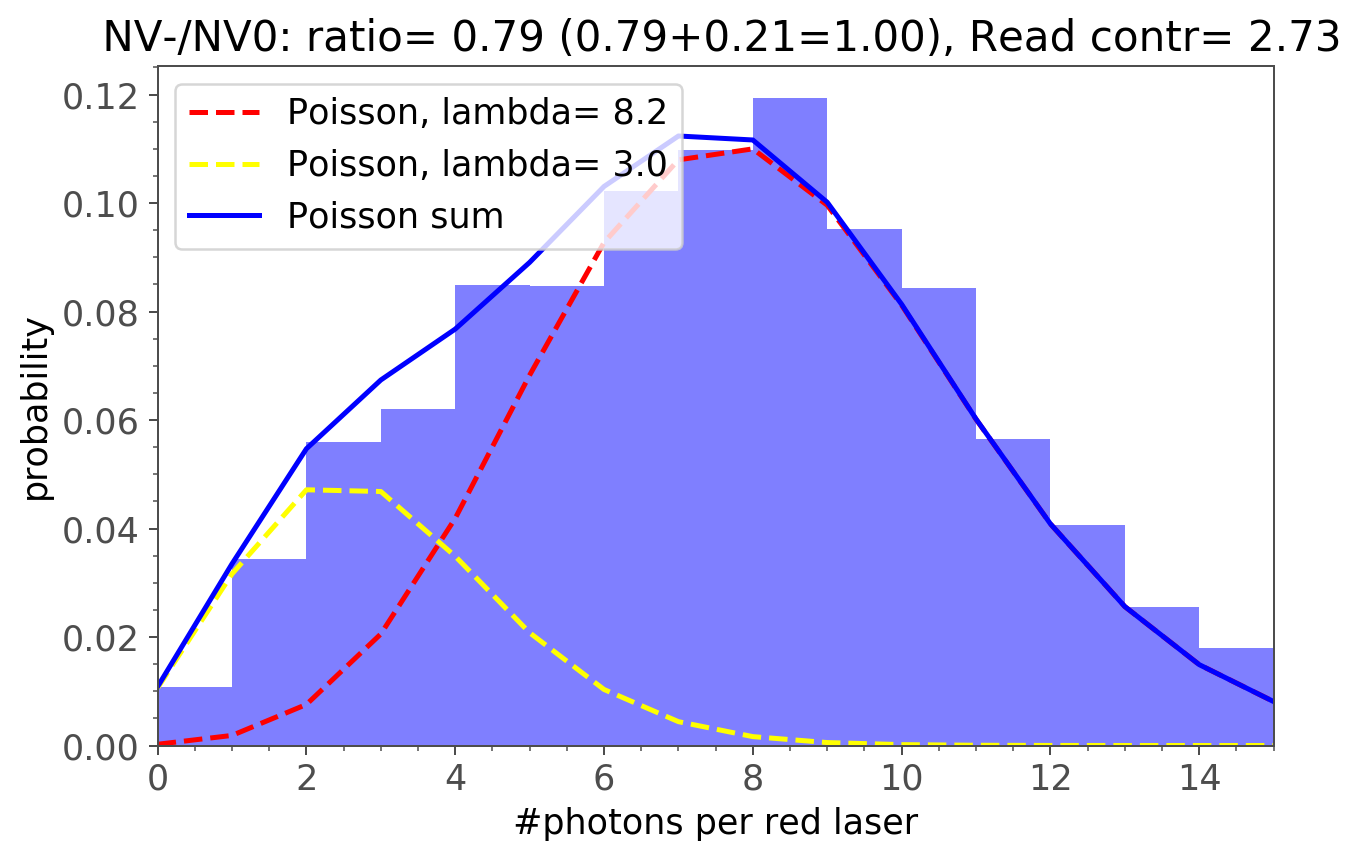

In [91]:
contr_nv_min_0 = 260/400
ampl_nv_min_0 = [2*0.789, 2*0.209]
#ampl_nv_min_0 = [2*0, 2*(1-0.45)]
ampl_sum = ampl_nv_min_0[0] + ampl_nv_min_0[1]

t_laser = 30e-3
cts = 2500 


lambda_nv_min = 52 #t_laser*cts
#lambda_nv_min = t_laser*cts
lambda_nv_0 = contr_nv_min_0*lambda_nv_min


lambda_nv_min = 8.15 #t_laser*cts
lambda_nv_0 = 2.98


ratio_nv_min_0 = ampl_nv_min_0[0]/ampl_sum

x = np.arange(0, 100, 1)
#x = np.linspace(0, 100, 1000)
y_poisson_sum = np.zeros((len(x)))
y_poisson_fits = []
colors = ['red', 'yellow']

plt.figure(figsize=(8,5))
for idx, pois_lambda in enumerate([lambda_nv_min, lambda_nv_0]):
    y_poisson = ampl_nv_min_0[idx]*poisson.pmf(x, mu=pois_lambda)/(2)
    y_poisson_fits.append(y_poisson)
    y_poisson_sum += y_poisson
    plt.plot(x, y_poisson, label=f'Poisson, lambda= {pois_lambda:.1f}',
             linestyle='dashed', marker='', color=colors[idx])

plt.plot(x, y_poisson_sum, label=f'Poisson sum',
         color='blue',  marker='')


#y_hist_abs, _, _ = plt.hist(res['time_trace'], bins=np.max(res['time_trace']), density=False,
#                             color='blue', alpha=0.5)#,  histtype='step')
y_hist, x_hist, _ = plt.hist(res['time_trace'], bins=np.max(res['time_trace']), density=True,
                             color='blue', alpha=0.5)#,  histtype='step')

x_hist = x_hist[:-1]


plt.title(f" NV-/NV0: ratio= {ratio_nv_min_0:.2f} ({ampl_nv_min_0[0]/2:.2f}+{ampl_nv_min_0[1]/2:.2f}={ampl_sum/2:.2f}), "
          f"Read contr= {lambda_nv_min/lambda_nv_0:.2f}")

plt.xlim([0,15])

plt.xlabel("#photons per red laser")
plt.ylabel("probability")
plt.legend()
plt.show()

In [87]:
qdplotlogic.set_data(x_hist[y_hist!=0], y_hist[y_hist!=0])


0

In [80]:
x_hist

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19.])

In [126]:
y_hist

array([0.00181449, 0.00090725, 0.00090725, 0.        , 0.00272174,
       0.00725797, 0.00362898, 0.        , 0.01451593, 0.01270144,
       0.01814491, 0.        , 0.02993911, 0.04354779, 0.04717677,
       0.        , 0.05443474, 0.07711588, 0.07802313, 0.        ,
       0.09526079, 0.09435355, 0.06532169, 0.        , 0.09707529,
       0.09072457, 0.07983762, 0.        , 0.06713618, 0.08165211,
       0.05352749, 0.        , 0.05443474, 0.04626953, 0.02903186,
       0.        , 0.02449563, 0.0217739 , 0.00816521, 0.        ,
       0.01088695, 0.00635072, 0.0099797 , 0.        , 0.00362898,
       0.00181449, 0.00362898, 0.        , 0.00090725, 0.        ,
       0.00090725, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00090725])